# 2 The Solow model with a time-varying savings rate

In [ ]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import numpy as np
from scipy.optimize import root_scalar
from scipy.optimize import minimize

### 2.1 Question 1

#### 2.1.1 Steady state
Using the analytical formulas with $s=\bar{s}=0.25$, the steady-state values are:

- $k^*=0.760726$
- $y^*=0.912871$
- $c^*=0.684653$

The root finder confirms the same steady-state capital:

- $k^*=0.760726$

#### 2.1.2 Baseline simulation
The model is simulated for 100 periods with a constant savings rate of $s_t=0.25$.

The reported values are:

- $c_0=0.348119$
- $c_{T-1}=0.684653$
- $k_{T-1}=0.760726$

#### 2.1.3 Simulator test
The simulator passes both tests:

- An economy starting at $k^*$ remains at the steady state.
- With $s_t=0$, capital follows $k_t=(1-\delta)^t k_0$.


k* = 0.760726
y* = 0.912871
c* = 0.684653
k* (root finder) = 0.760726


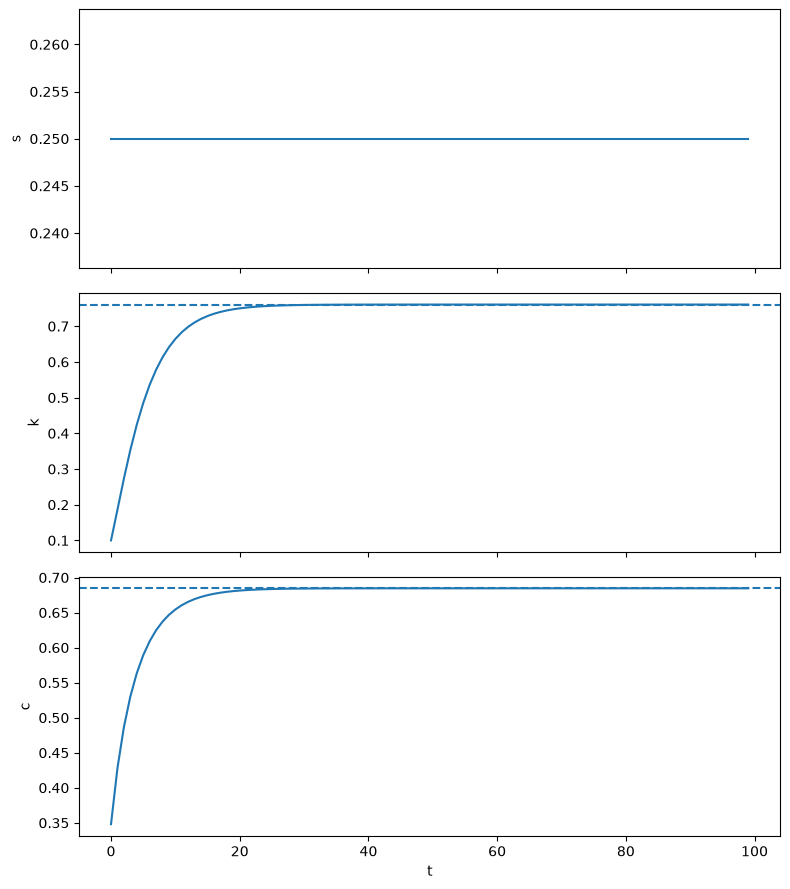

c0 = 0.348119
c(T-1) = 0.684653
k(T-1) = 0.760726


In [5]:
# Parameters
alpha = 1/3
delta = 0.30
s_bar = 0.25
beta = 1/1.2
T = 100
k0 = 0.10

# Steady state (analytical)
k_star = (s_bar / delta) ** (1 / (1 - alpha))
y_star = k_star ** alpha
c_star = (1 - s_bar) * y_star

print(f"k* = {k_star:.6f}")
print(f"y* = {y_star:.6f}")
print(f"c* = {c_star:.6f}")

# Steady state (root finder)
def steady_state_eq(k):
    return s_bar * k**alpha + (1 - delta) * k - k

sol = root_scalar(steady_state_eq, bracket=[1e-8, 100], method="brentq")
print(f"k* (root finder) = {sol.root:.6f}")

# Simulator with constant savings rate
def simulate_solow(k0, s, alpha, delta, T):
    k = np.empty(T)
    y = np.empty(T)
    c = np.empty(T)
    s_path = np.full(T, s)

    k[0] = k0
    for t in range(T):
        y[t] = k[t] ** alpha
        c[t] = (1 - s) * y[t]
        if t < T - 1:
            k[t + 1] = s * y[t] + (1 - delta) * k[t]

    return k, y, c, s_path

# Baseline simulation
k, y, c, s_path = simulate_solow(k0, s_bar, alpha, delta, T)

# Figure
fig, ax = plt.subplots(3, 1, figsize=(8, 9), sharex=True)

ax[0].plot(s_path)
ax[0].set_ylabel("s")

ax[1].plot(k)
ax[1].axhline(k_star, ls="--")
ax[1].set_ylabel("k")

ax[2].plot(c)
ax[2].axhline(c_star, ls="--")
ax[2].set_ylabel("c")
ax[2].set_xlabel("t")

plt.tight_layout()
plt.show()

print(f"c0 = {c[0]:.6f}")
print(f"c(T-1) = {c[-1]:.6f}")
print(f"k(T-1) = {k[-1]:.6f}")

# Tests
k_test, _, _, _ = simulate_solow(k_star, s_bar, alpha, delta, 20)
assert np.allclose(k_test, k_star)

k_decay, _, _, _ = simulate_solow(k0, 0.0, alpha, delta, 20)
assert np.allclose(k_decay, k0 * (1 - delta) ** np.arange(20))

### 2.2 Question 2
#### 2.2.1-2 Time-varying savings rule and simulations
The savings rule was implemented as

$$
s_t=\bar{s}+(s_0-\bar{s})\phi^t
$$

and the model was simulated for all four parameter combinations together with the baseline.

#### 2.2.3 Final capital
| Case | $k_{T-1}$ |
|---|---:|
| Baseline | 0.760726 |
| $s_0=0.30,\ \phi=0.50$ | 0.760726 |
| $s_0=0.40,\ \phi=0.80$ | 0.760726 |
| $s_0=0.10,\ \phi=0.50$ | 0.760726 |
| $s_0=0.60,\ \phi=0.60$ | 0.760726 |

All five cases end with the same final capital.

#### 2.2.4 Interpretation
- A higher $s_0$ increases savings in the first periods, while a lower $s_0$ reduces initial savings.
- A higher $\phi$ makes the savings rate return more slowly toward $\bar{s}$, while a lower $\phi$ makes it return more quickly.


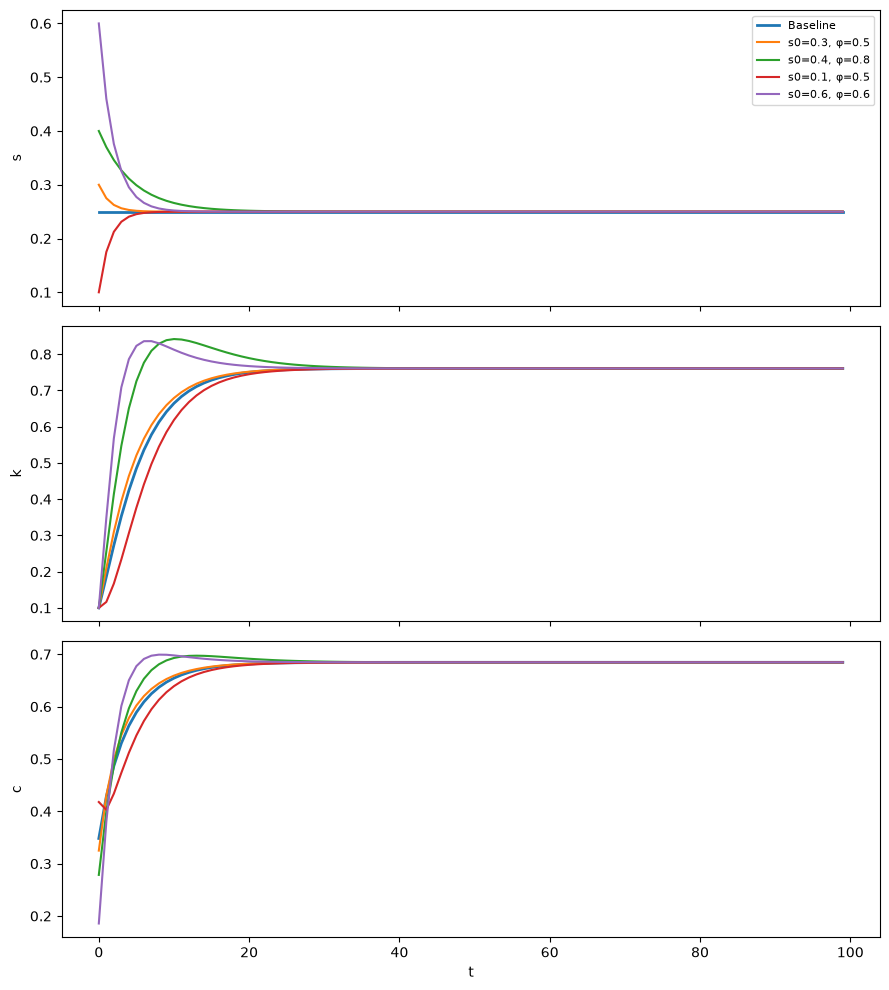

Baseline: k(T-1) = 0.760726
s0=0.3, φ=0.5: k(T-1) = 0.760726
s0=0.4, φ=0.8: k(T-1) = 0.760726
s0=0.1, φ=0.5: k(T-1) = 0.760726
s0=0.6, φ=0.6: k(T-1) = 0.760726


In [6]:
# Savings rule
def savings_rule(s0, phi, s_bar, T):
    t = np.arange(T)
    return s_bar + (s0 - s_bar) * phi**t

# Simulator with time-varying savings rate
def simulate_solow_variable(k0, s0, phi, alpha, delta, s_bar, T):
    k = np.empty(T)
    y = np.empty(T)
    c = np.empty(T)
    s_path = savings_rule(s0, phi, s_bar, T)

    k[0] = k0
    for t in range(T):
        y[t] = k[t]**alpha
        c[t] = (1 - s_path[t]) * y[t]
        if t < T - 1:
            k[t+1] = s_path[t] * y[t] + (1 - delta) * k[t]

    return k, y, c, s_path

# Baseline (from Question 2.1)
baseline = {"k": k, "y": y, "c": c, "s": s_path}

# Four combinations
cases = [
    (0.30, 0.50),
    (0.40, 0.80),
    (0.10, 0.50),
    (0.60, 0.60),
]

results = {}

# Simulate all cases
for s0, phi in cases:
    k_i, y_i, c_i, s_i = simulate_solow_variable(
        k0, s0, phi, alpha, delta, s_bar, T
    )
    results[(s0, phi)] = {
        "k": k_i,
        "y": y_i,
        "c": c_i,
        "s": s_i,
    }

# Plot
fig, ax = plt.subplots(3, 1, figsize=(9, 10), sharex=True)

# Savings rate
ax[0].plot(baseline["s"], lw=2, label="Baseline")
for (s0, phi), res in results.items():
    ax[0].plot(res["s"], label=f"s0={s0}, φ={phi}")
ax[0].set_ylabel("s")
ax[0].legend(fontsize=8)

# Capital
ax[1].plot(baseline["k"], lw=2, label="Baseline")
for (s0, phi), res in results.items():
    ax[1].plot(res["k"], label=f"s0={s0}, φ={phi}")
ax[1].set_ylabel("k")

# Consumption
ax[2].plot(baseline["c"], lw=2, label="Baseline")
for (s0, phi), res in results.items():
    ax[2].plot(res["c"], label=f"s0={s0}, φ={phi}")
ax[2].set_ylabel("c")
ax[2].set_xlabel("t")

plt.tight_layout()
plt.show()

# Report k(T-1)
print(f"Baseline: k(T-1) = {baseline['k'][-1]:.6f}")
for (s0, phi), res in results.items():
    print(f"s0={s0}, φ={phi}: k(T-1) = {res['k'][-1]:.6f}")

### 2.3 Question 3
#### 2.3.1–2 Welfare results

| Case | $W$ | $W-W_{\text{baseline}}$ |
|---|---:|---:|
| Baseline | -3.9944 | 0.0000 |
| $s_0=0.30,\ \phi=0.50$ | -3.9857 | 0.0087 |
| $s_0=0.40,\ \phi=0.80$ | -4.0914 | -0.0970 |
| $s_0=0.10,\ \phi=0.50$ | -4.1460 | -0.1516 |
| $s_0=0.60,\ \phi=0.60$ | -4.3407 | -0.3463 |

#### 2.3.3 Comparison

Only the combination $s_0=0.30,\ \phi=0.50$ gives higher welfare than the baseline.

The figure alone does not clearly identify which combination gives the highest welfare, because welfare depends on discounted consumption over the entire path rather than only on the visual appearance of the curves.


In [7]:
# Welfare function
def welfare(c, beta):
    t = np.arange(len(c))
    return np.sum(beta**t * np.log(c))

# Compute welfare
W_baseline = welfare(baseline["c"], beta)

print(f"{'Case':<20}{'W':>12}{'ΔW':>12}")
print("-"*44)
print(f"{'Baseline':<20}{W_baseline:>12.4f}{0:>12.4f}")

for (s0, phi), res in results.items():
    W = welfare(res["c"], beta)
    print(f"s0={s0}, φ={phi:<6}{W:>12.4f}{W-W_baseline:>12.4f}")

Case                           W          ΔW
--------------------------------------------
Baseline                 -3.9944      0.0000
s0=0.3, φ=0.5        -3.9857      0.0087
s0=0.4, φ=0.8        -4.0914     -0.0970
s0=0.1, φ=0.5        -4.1460     -0.1516
s0=0.6, φ=0.6        -4.3407     -0.3463


### 2.4 Question 4

#### 2.4.1 Grid search
The best grid point is:

- $s_0=0.310$
- $\phi=0.230$
- $W=-3.9843$

#### 2.4.2 Numerical optimization
The optimizer finds:

- $s_0=0.3115$
- $\phi=0.2208$
- $W=-3.9843$

The optimized solution is almost identical to the best grid point.

#### 2.4.3 Best rule compared with the baseline
The optimized rule gives:

- $c_0=0.319575$

Consumption exceeds the baseline for the first time in period 1.

Best grid point
s0 = 0.310
phi = 0.230
W = -3.9843


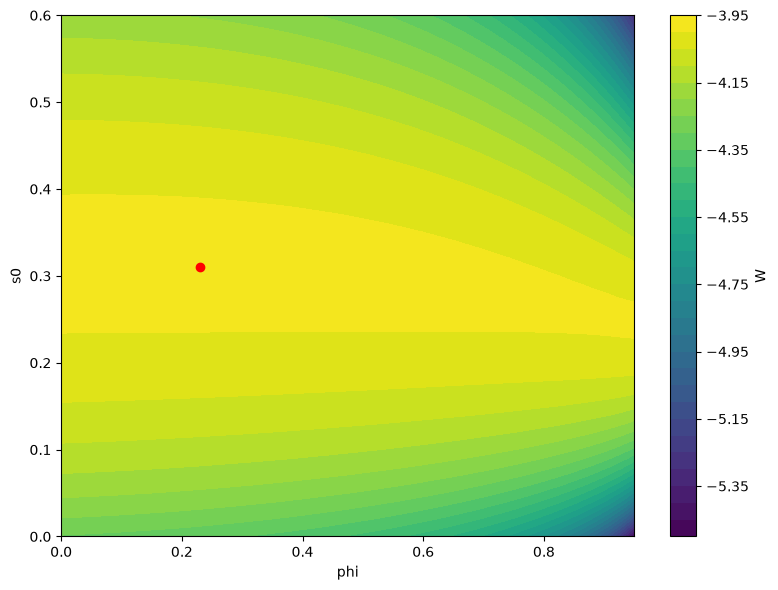


Optimized solution
s0 = 0.3115
phi = 0.2208
W = -3.9843


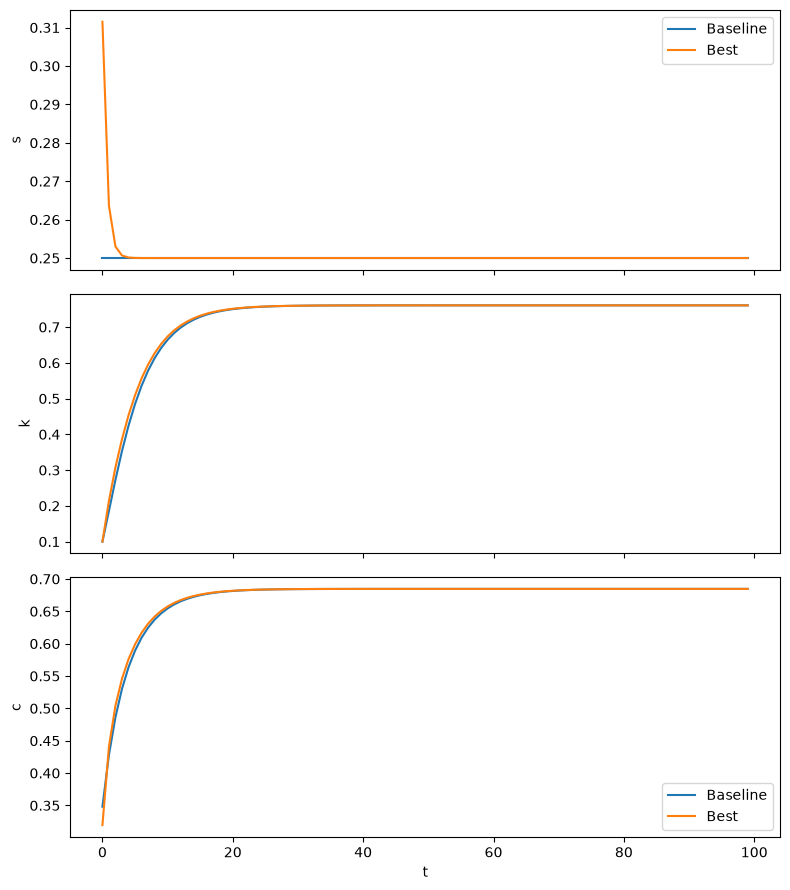

c0 = 0.319575
First period with c above baseline: 1


In [ ]:
# Grid search
s0_grid = np.linspace(0, 0.60, 61)
phi_grid = np.linspace(0, 0.95, 96)

W_grid = np.empty((len(s0_grid), len(phi_grid)))

for i, s0 in enumerate(s0_grid):
    for j, phi in enumerate(phi_grid):
        _, _, c, _ = simulate_solow_variable(
            k0, s0, phi, alpha, delta, s_bar, T
        )
        W_grid[i, j] = welfare(c, beta)

best_idx = np.unravel_index(np.argmax(W_grid), W_grid.shape)
best_s0 = s0_grid[best_idx[0]]
best_phi = phi_grid[best_idx[1]]
best_W = W_grid[best_idx]

print("Best grid point")
print(f"s0 = {best_s0:.3f}")
print(f"phi = {best_phi:.3f}")
print(f"W = {best_W:.4f}")

# Contour plot
plt.figure(figsize=(8,6))
plt.contourf(phi_grid, s0_grid, W_grid, levels=30)
plt.colorbar(label="W")
plt.scatter(best_phi, best_s0, color="red")
plt.xlabel("phi")
plt.ylabel("s0")
plt.tight_layout()
plt.show()

# Numerical optimization
def objective(x):
    s0, phi = x
    if not (0 <= s0 <= 0.60 and 0 <= phi <= 0.95):
        return 1e10
    _, _, c, _ = simulate_solow_variable(
        k0, s0, phi, alpha, delta, s_bar, T
    )
    return -welfare(c, beta)

opt = minimize(
    objective,
    x0=[best_s0, best_phi],
    bounds=[(0,0.60),(0,0.95)]
)

opt_s0, opt_phi = opt.x
opt_W = -opt.fun

print("\nOptimized solution")
print(f"s0 = {opt_s0:.4f}")
print(f"phi = {opt_phi:.4f}")
print(f"W = {opt_W:.4f}")

# Plot optimized path
k_opt, y_opt, c_opt, s_opt = simulate_solow_variable(
    k0, opt_s0, opt_phi, alpha, delta, s_bar, T
)

fig, ax = plt.subplots(3,1,figsize=(8,9),sharex=True)

ax[0].plot(baseline["s"], label="Baseline")
ax[0].plot(s_opt, label="Best")
ax[0].legend()
ax[0].set_ylabel("s")

ax[1].plot(baseline["k"])
ax[1].plot(k_opt)
ax[1].set_ylabel("k")

ax[2].plot(baseline["c"], label="Baseline")
ax[2].plot(c_opt, label="Best")
ax[2].legend()
ax[2].set_ylabel("c")
ax[2].set_xlabel("t")

plt.tight_layout()
plt.show()

# First period where consumption exceeds baseline
above = np.where(c_opt > baseline["c"])[0]
first_above = above[0] if len(above) > 0 else None

print(f"c0 = {c_opt[0]:.6f}")
print(f"First period with c above baseline: {first_above}")

### 2.5 Question 5

#### 2.5.1 Three-parameter optimization

The optimal parameters are:

- $s_0=0.3139$
- $\phi=0.6708$
- $s_\infty=0.1989$

The resulting welfare is:

- $W=-3.9670$

This improves welfare by 0.0173 compared with Question 2.4.

#### 2.5.2 Final capital

- $k_{T-1}=0.540025$
- $k^*=0.760726$

The final capital is not equal to the steady-state capital from Question 2.1.

This is expected because the long-run savings rate is no longer fixed at $\bar{s}=0.25$.

In [9]:
# Simulator with free long-run savings rate
def simulate_solow_three(k0, s0, phi, s_inf, alpha, delta, T):
    k = np.empty(T)
    y = np.empty(T)
    c = np.empty(T)

    t = np.arange(T)
    s = s_inf + (s0 - s_inf) * phi**t

    k[0] = k0
    for i in range(T):
        y[i] = k[i]**alpha
        c[i] = (1-s[i]) * y[i]
        if i < T-1:
            k[i+1] = s[i]*y[i] + (1-delta)*k[i]

    return k, y, c, s

# Optimization
def objective3(x):
    s0, phi, s_inf = x
    if not (0 <= s0 <= 0.60 and 0 <= phi <= 0.95 and 0 <= s_inf <= 0.60):
        return 1e10

    _, _, c, _ = simulate_solow_three(
        k0, s0, phi, s_inf, alpha, delta, T
    )
    return -welfare(c, beta)

opt3 = minimize(
    objective3,
    x0=[opt_s0, opt_phi, s_bar],
    bounds=[(0,0.60),(0,0.95),(0,0.60)]
)

s0_best, phi_best, s_inf_best = opt3.x
W_best3 = -opt3.fun

k3, y3, c3, s3 = simulate_solow_three(
    k0, s0_best, phi_best, s_inf_best,
    alpha, delta, T
)

print(f"s0 = {s0_best:.4f}")
print(f"phi = {phi_best:.4f}")
print(f"s_inf = {s_inf_best:.4f}")
print(f"W = {W_best3:.4f}")
print(f"Improvement over Q2.4 = {W_best3-opt_W:.4f}")

print(f"k(T-1) = {k3[-1]:.6f}")
print(f"k* = {k_star:.6f}")

s0 = 0.3139
phi = 0.6708
s_inf = 0.1989
W = -3.9670
Improvement over Q2.4 = 0.0173
k(T-1) = 0.540025
k* = 0.760726


### 2.6 Question 6

#### 2.6.1–2 Alternative savings rule

An alternative exponential savings rule was implemented, and the optimized parameters are:

- $s_0=0.3139$
- $\phi=0.3993$
- $s_\infty=0.1989$

The resulting welfare is:

- $W=-3.9670$

#### 2.6.3 Welfare comparison

| Rule | $W$ |
|---|---:|
| Baseline | -3.9944 |
| Best Q2.4 | -3.9843 |
| Best Q2.5 | -3.9670 |
| Alternative | -3.9670 |

The alternative functional form matches the best welfare obtained in Question 2.5, so it does not outperform the three-parameter rule.

In [10]:
# Alternative savings rule
def simulate_solow_exp(k0, s0, phi, s_inf, alpha, delta, T):
    k = np.empty(T)
    y = np.empty(T)
    c = np.empty(T)

    t = np.arange(T)
    s = s_inf + (s0-s_inf)*np.exp(-phi*t)

    k[0] = k0
    for i in range(T):
        y[i] = k[i]**alpha
        c[i] = (1-s[i])*y[i]
        if i < T-1:
            k[i+1] = s[i]*y[i] + (1-delta)*k[i]

    return k, y, c, s

# Optimize alternative rule
def objective_exp(x):
    s0, phi, s_inf = x
    if not (0 <= s0 <= 0.60 and 0 <= phi <= 2 and 0 <= s_inf <= 0.60):
        return 1e10

    _, _, c, _ = simulate_solow_exp(
        k0, s0, phi, s_inf, alpha, delta, T
    )
    return -welfare(c, beta)

opt_exp = minimize(
    objective_exp,
    x0=[s0_best, 0.5, s_inf_best],
    bounds=[(0,0.60),(0,2),(0,0.60)]
)

s0_exp, phi_exp, s_inf_exp = opt_exp.x
W_exp = -opt_exp.fun

print(f"s0 = {s0_exp:.4f}")
print(f"phi = {phi_exp:.4f}")
print(f"s_inf = {s_inf_exp:.4f}")
print(f"W = {W_exp:.4f}")

# Summary table
print("\nSummary")
print(f"{'Rule':<20}{'W':>12}")
print("-"*32)
print(f"{'Baseline':<20}{W_baseline:>12.4f}")
print(f"{'Best Q2.4':<20}{opt_W:>12.4f}")
print(f"{'Best Q2.5':<20}{W_best3:>12.4f}")
print(f"{'Alternative':<20}{W_exp:>12.4f}")

s0 = 0.3139
phi = 0.3993
s_inf = 0.1989
W = -3.9670

Summary
Rule                           W
--------------------------------
Baseline                 -3.9944
Best Q2.4                -3.9843
Best Q2.5                -3.9670
Alternative              -3.9670
